In [1]:
# Mount to Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from matplotlib.pyplot import figure
%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (15,10)

import numpy as np
import seaborn as sns

In [3]:
# Read the data
file_path = '/content/drive/MyDrive/MOVIES/movies.csv'
df = pd.read_csv(file_path)

df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [4]:
# Missing value
for col in df.columns:
  pct_missing = np.mean(df[col].isnull())
  print("{} - {}%".format(col, pct_missing))

name - 0.0%
rating - 0.010041731872717789%
genre - 0.0%
year - 0.0%
released - 0.0002608242044861763%
score - 0.0003912363067292645%
votes - 0.0003912363067292645%
director - 0.0%
writer - 0.0003912363067292645%
star - 0.00013041210224308815%
country - 0.0003912363067292645%
budget - 0.2831246739697444%
gross - 0.02464788732394366%
company - 0.002217005738132499%
runtime - 0.0005216484089723526%


In [5]:
# Data type of columns
df.dtypes

,0
name,object
rating,object
genre,object
year,int64
released,object
score,float64
votes,float64
director,object
writer,object
star,object


In [6]:
# Change data type of columns
df['budget'] = df['budget'].replace([np.inf, -np.inf], np.nan).fillna(0).astype('int64')
df['gross'] = df['gross'].replace([np.inf, -np.inf], np.nan).fillna(0).astype('int64')

In [7]:
# Change data type of date
df['released'] = df['released'].str.extract(r'([A-Za-z]+\s\d{1,2},\s\d{4})')[0]
df['released'] = pd.to_datetime(df['released'])
df['yearcorrect'] = df['released'].dt.year

In [8]:
df.sort_values(by=["gross"], inplace=False, ascending=False)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
5445,Avatar,PG-13,Action,2009,2009-12-18,7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0,2009.0
7445,Avengers: Endgame,PG-13,Action,2019,2019-04-26,8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,2019.0
3045,Titanic,PG-13,Drama,1997,1997-12-19,7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0,1997.0
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,2015-12-18,7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138.0,2015.0
7244,Avengers: Infinity War,PG-13,Action,2018,2018-04-27,8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0,2018.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,2020-10-23,3.1,18.0,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000,0,NaN,90.0,2020.0
641,Blame It on the Night,PG-13,Comedy,1984,1984-11-02,5.1,172.0,Gene Taft,Gene Taft,Nick Mancuso,United States,0,0,Delphi II Productions,85.0,1984.0
7658,Black Wall Street Burning,R,Drama,2020,2020-02-07,6.6,35.0,Marcus Brown,Dekoven Riggins,Dan Belcher,United States,5000,0,Notis Studio,78.0,2020.0
671,Flesh+Blood,R,Adventure,1985,1985-08-30,6.7,17000.0,Paul Verhoeven,Gerard Soeteman,Rutger Hauer,Netherlands,6500000,0,Riverside Pictures,126.0,1985.0


In [9]:
# Drop duplicated
df.drop_duplicates()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
0,The Shining,R,Drama,1980,1980-06-13,8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146.0,1980.0
1,The Blue Lagoon,R,Adventure,1980,1980-07-02,5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104.0,1980.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,1980-06-20,8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124.0,1980.0
3,Airplane!,PG,Comedy,1980,1980-07-02,7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88.0,1980.0
4,Caddyshack,R,Comedy,1980,1980-07-25,7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98.0,1980.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,2020-10-23,3.1,18.0,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000,0,NaN,90.0,2020.0
7664,Dream Round,NaN,Comedy,2020,2020-02-07,4.7,36.0,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,0,0,Cactus Blue Entertainment,90.0,2020.0
7665,Saving Mbango,NaN,Drama,2020,2020-04-27,5.7,29.0,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,58750,0,Embi Productions,NaN,2020.0
7666,It's Just Us,NaN,Drama,2020,2020-10-01,NaN,NaN,James Randall,James Randall,Christina Roz,United States,15000,0,NaN,120.0,2020.0


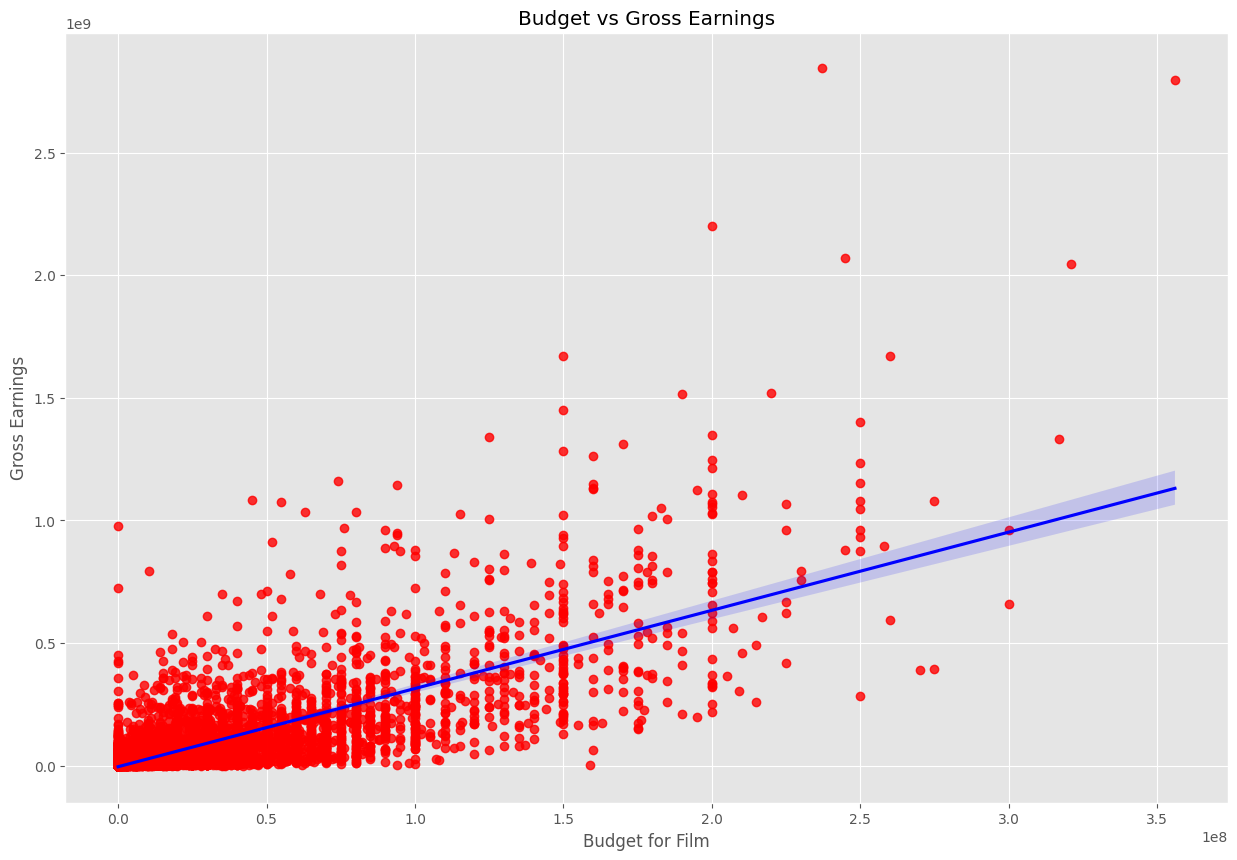

In [10]:
# Scatter plot with bugdet and gross
sns.regplot(
    x='budget',
    y='gross',
    data=df,
    scatter_kws={"color": "red"},
    line_kws={"color": "blue"}
)
plt.title('Budget vs Gross Earnings')
plt.xlabel('Budget for Film')
plt.ylabel('Gross Earnings')
plt.show()

In [11]:
df.corr(numeric_only=True, method="pearson")

,year,score,votes,budget,gross,runtime,yearcorrect
year,1.000000,0.097995,0.222945,0.309212,0.261900,0.120811,0.997596
score,0.097995,1.000000,0.409182,0.055665,0.186392,0.399451,0.108188
votes,0.222945,0.409182,1.000000,0.486862,0.632834,0.309212,0.216092
budget,0.309212,0.055665,0.486862,1.000000,0.750157,0.269510,0.297674
gross,0.261900,0.186392,0.632834,0.750157,1.000000,0.245235,0.253253
runtime,0.120811,0.399451,0.309212,0.269510,0.245235,1.000000,0.120084
yearcorrect,0.997596,0.108188,0.216092,0.297674,0.253253,0.120084,1.000000


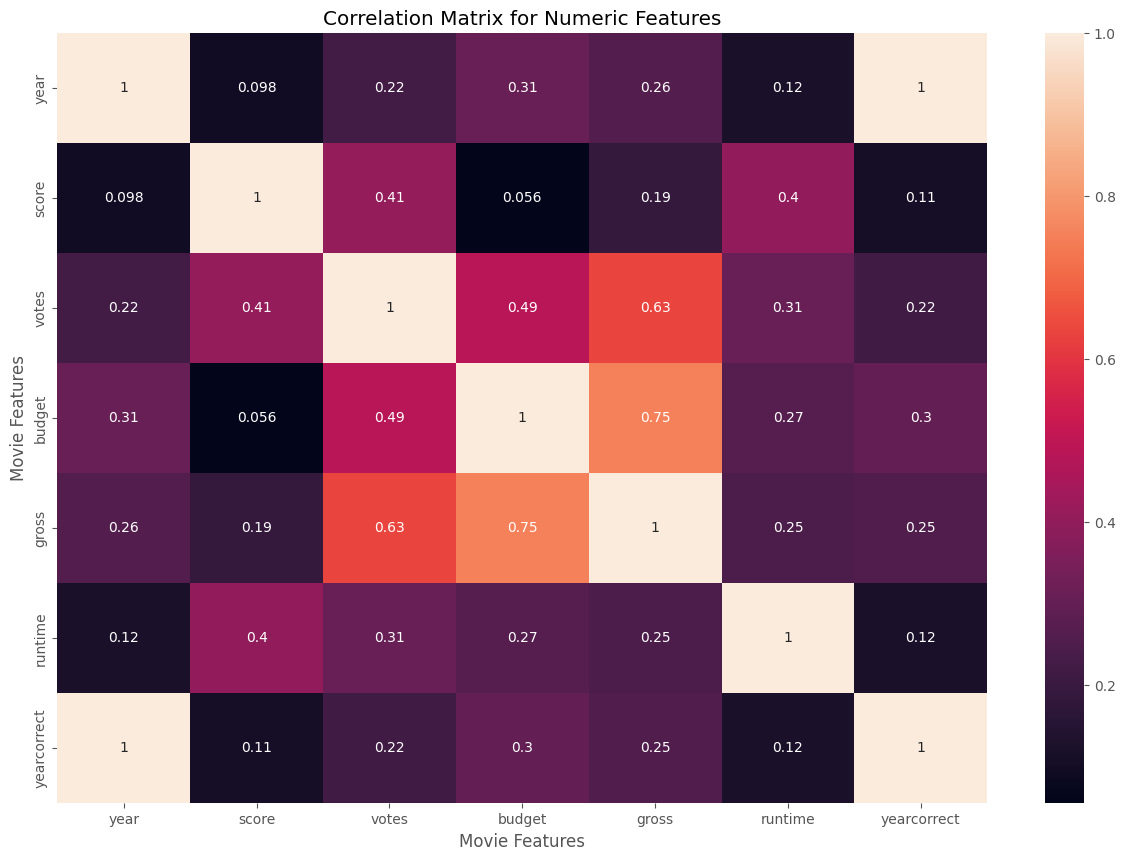

In [12]:
# High correlation between budget and gross
correlation_matrix = df.corr(numeric_only=True, method="pearson")
sns.heatmap(correlation_matrix, annot=True)
plt.title("Correlation Matrix for Numeric Features")
plt.xlabel("Movie Features")
plt.ylabel("Movie Features")
plt.show()

In [13]:
df_numerized = df
for col_name in df_numerized.columns:
  if(df_numerized[col_name].dtype == 'object'):
    df_numerized[col_name] = df_numerized[col_name].astype('category')
    df_numerized[col_name] = df_numerized[col_name].cat.codes

df_numerized

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
0,6587,6,6,1980,1980-06-13,8.4,927000.0,2589,4014,1047,54,19000000,46998772,2319,146.0,1980.0
1,5573,6,1,1980,1980-07-02,5.8,65000.0,2269,1632,327,55,4500000,58853106,731,104.0,1980.0
2,5142,4,0,1980,1980-06-20,8.7,1200000.0,1111,2567,1745,55,18000000,538375067,1540,124.0,1980.0
3,286,4,4,1980,1980-07-02,7.7,221000.0,1301,2000,2246,55,3500000,83453539,1812,88.0,1980.0
4,1027,6,4,1980,1980-07-25,7.3,108000.0,1054,521,410,55,6000000,39846344,1777,98.0,1980.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,3705,-1,6,2020,2020-10-23,3.1,18.0,1500,2289,2421,55,7000,0,-1,90.0,2020.0
7664,1678,-1,4,2020,2020-02-07,4.7,36.0,774,2614,1886,55,0,0,539,90.0,2020.0
7665,4717,-1,6,2020,2020-04-27,5.7,29.0,2061,2683,2040,55,58750,0,941,NaN,2020.0
7666,2843,-1,6,2020,2020-10-01,NaN,NaN,1184,1824,450,55,15000,0,-1,120.0,2020.0


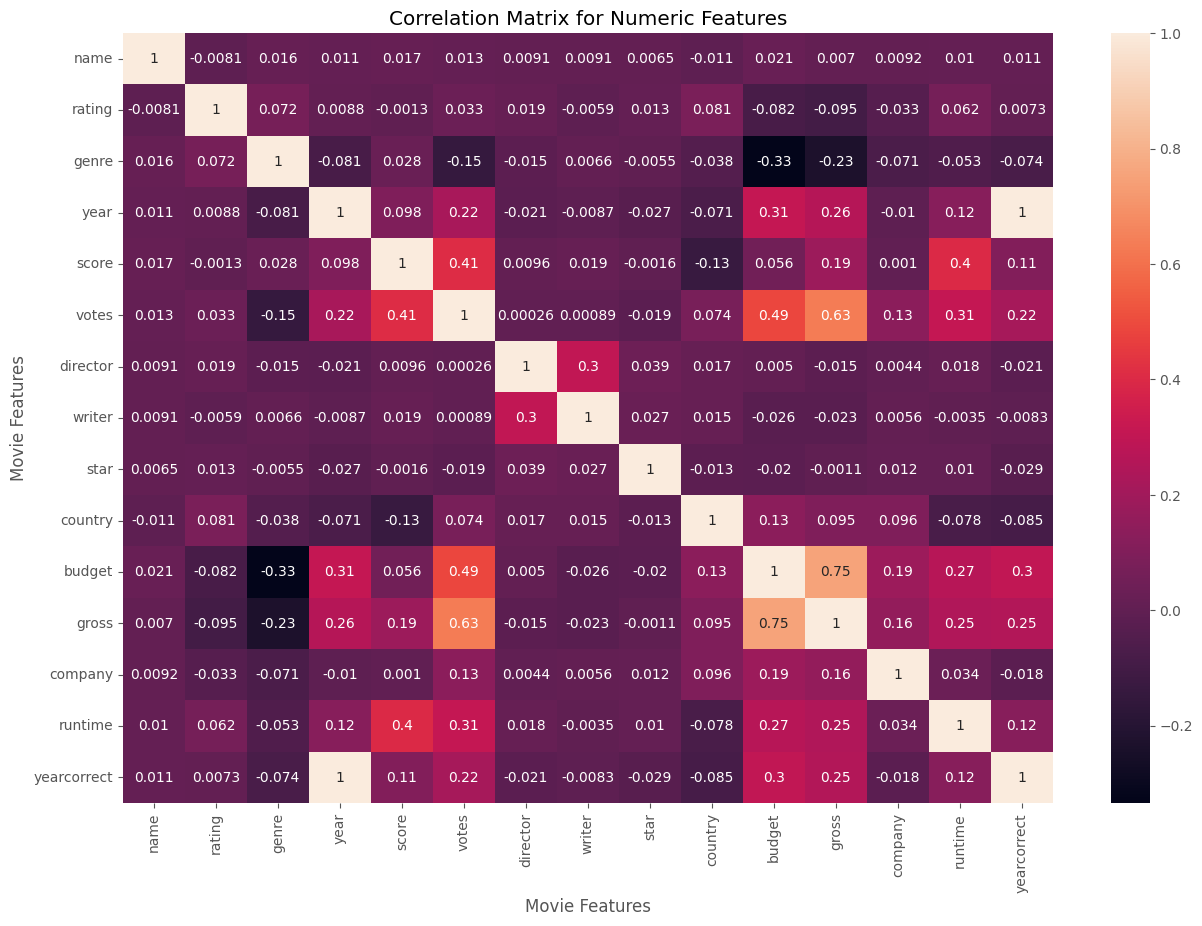

In [14]:
# High correlation between budget and gross
correlation_matrix = df_numerized.corr(numeric_only=True, method="pearson")
sns.heatmap(correlation_matrix, annot=True)
plt.title("Correlation Matrix for Numeric Features")
plt.xlabel("Movie Features")
plt.ylabel("Movie Features")
plt.show()

In [20]:
correlation_mat = df_numerized.corr()
corr_pairs = correlation_mat.unstack()
corr_pairs

name         name           1.000000
             rating        -0.008069
             genre          0.016355
             year           0.011453
             released      -0.004951
                              ...   
yearcorrect  budget         0.297674
             gross          0.253253
             company       -0.018447
             runtime        0.120084
             yearcorrect    1.000000
Length: 256, dtype: float64

In [21]:
sorted_pairs = corr_pairs.sort_values()
sorted_pairs

genre        budget        -0.334021
budget       genre         -0.334021
gross        genre         -0.234297
genre        gross         -0.234297
             votes         -0.145307
                              ...   
star         star           1.000000
company      company        1.000000
gross        gross          1.000000
runtime      runtime        1.000000
yearcorrect  yearcorrect    1.000000
Length: 256, dtype: float64

In [18]:
high_corr = sorted_pairs[(sorted_pairs)>0.5]
high_corr

,,0
votes,gross,0.632834
gross,votes,0.632834
budget,gross,0.750157
gross,budget,0.750157
yearcorrect,year,0.997596
year,yearcorrect,0.997596
released,yearcorrect,0.999668
yearcorrect,released,0.999668
director,director,1.000000
votes,votes,1.000000
